# Setup

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)



# Q1 Logistic Regression Intution

What is logistic regression, and why is it used instead of linear regression when the target variable is categorical (e.g. malignant vs. benign) rather than continuous? Define the sigmoid function `sigmoid(z) = 1 / (1 + e⁻ᶻ)` and explain how it transforms the output of a linear equation into something usable as a probability.


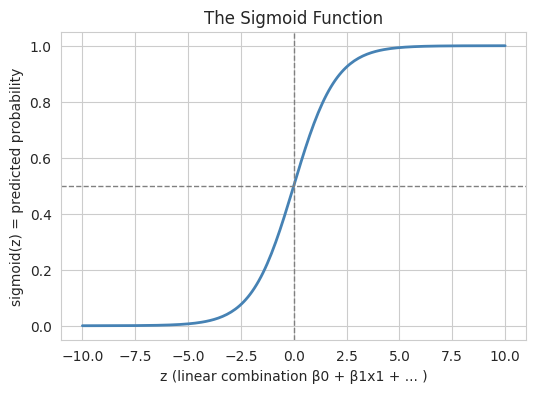

sigmoid(-10) = 0.000045
sigmoid(0)   = 0.500000
sigmoid(10)  = 0.999955


In [3]:
# Visualize the sigmoid function to build intuition
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)
p = sigmoid(z)

plt.figure(figsize=(6, 4))
plt.plot(z, p, color='steelblue', linewidth=2)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel("z (linear combination β0 + β1x1 + ... )")
plt.ylabel("sigmoid(z) = predicted probability")
plt.title("The Sigmoid Function")
plt.show()

print(f"sigmoid(-10) = {sigmoid(-10):.6f}")
print(f"sigmoid(0)   = {sigmoid(0):.6f}")
print(f"sigmoid(10)  = {sigmoid(10):.6f}")


## Q2. Load and Explore the Dataset
Load the Breast Cancer Wisconsin dataset and explore it. Report the shape of the data, the list of feature names, and the class balance of `target` (counts and percentages). Based on the class balance, would accuracy alone be a trustworthy metric for this dataset? Why or why not?


In [ ]:

 #Load the breast cancer dataset from sklearn


# Create a DataFrame for features and a Series for the target



In [ ]:
# Display dataset information
print("Shape of X:", X.shape)
print("\nFeature names:")

print(list(data.feature_names))
print("\nTarget classes:", dict(enumerate(data.target_names)))



In [ ]:
# Display class balance
print("\nClass balance (counts):")
print(y.value_counts())
print("\nClass balance (percentages):")
print((y.value_counts(normalize=True) * 100).round(2))


In [ ]:
# Visualize class balance
plt.figure(figsize=(5, 4))
sns.countplot(x=y.map({0: 'malignant (0)', 1: 'benign (1)'}), palette=['indianred', 'steelblue'])
plt.title("Class Balance: Target")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()


## Q3. Odds, Log-Odds, and the Logit Equation
Logistic regression models the log-odds of the positive class as a linear function of the predictors: `log(p / (1-p)) = β0 + β1x1 + ... + βnxn`. What do "odds" and "log-odds" mean in plain terms? Work through a numeric example: for a predicted probability of `p = 0.8`, calculate the corresponding odds and log-odds by hand, and explain how the sigmoid function (Q1) relates to this equation.


In [ ]:
# Numeric example: p = 0.8
p = 0.8

odds = p / (1 - p)
log_odds = np.log(odds)

print(f"p (probability)      = {p}")
print(f"odds = p / (1-p)      = {odds}")
print(f"log-odds = log(odds)  = {log_odds:.4f}")

# Verify the sigmoid function recovers p from the log-odds (z)
z = log_odds
p_recovered = 1 / (1 + np.exp(-z))
print(f"\nsigmoid(log-odds) = {p_recovered:.4f}  (should match p = {p})")



## Q4. Train/Test Split, Scaling, and Model Fitting
Split the data into training (80%) and test (20%) sets using `train_test_split` with `random_state=42`. Scale the features using `StandardScaler`, fitting it on the training data only. Why must the scaler be fit on the training set only, and then used to transform the test set, rather than fitting a separate scaler on the test data? Fit a `LogisticRegression` model on the scaled training data and report the intercept and number of coefficients.


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Create Train and Test Set





print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

# Fit the scaler ONLY on the training data




# Use the SAME fitted scaler to transform the test data



# Fit logistic regression on the scaled training data


print("\nIntercept (β0):", model.intercept_)
print("Number of coefficients:", model.coef_.shape[1])
print("\nFirst 5 coefficients:", model.coef_[0][:5])


## Q5. Predictions and the Confusion Matrix
Generate class predictions (`.predict`) and predicted probabilities (`.predict_proba`) for the test set. Build and visualize the confusion matrix. Label which cell corresponds to true positives, true negatives, false positives, and false negatives in this medical diagnosis context.


In [ ]:
# import metrics for evaluation
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                              precision_score, recall_score, f1_score, classification_report,
                              roc_curve, auc)


# Evaluate the model on the test set
y_pred = model.predict(X_test_scaled)

y_proba = model.predict_proba(X_test_scaled)[:, 1]   # probability of class 1 (benign)

print("First 10 predicted classes:     ", y_pred[:10])
print("First 10 predicted probabilities:", np.round(y_proba[:10], 3))

# Compute and display the confusion matrix

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (rows=actual, cols=predicted):")
print(cm)


# Visualize the confusion matrix
fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['malignant (0)', 'benign (1)'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix — Test Set")
plt.show()

# Compute and display the confusion matrix values
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly predicted malignant): {tn}")
print(f"False Positives (predicted benign, actually malignant): {fp}")
print(f"False Negatives (predicted malignant, actually benign): {fn}")
print(f"True Positives  (correctly predicted benign): {tp}")




## Q6. Classification Metrics and Their Clinical Cost
Compute Accuracy, Precision, Recall, and F1-score for the positive class. In this medical context (1 = benign, 0 = malignant), what does a false negative (predicting benign when the tumor is actually malignant) cost compared to a false positive (predicting malignant when the tumor is actually benign)? Which metric should be prioritized here, and why?


In [ ]:
# Compute Accuracy Score
accuracy = accuracy_score(y_test, y_pred)

# Compute Precision
precision = precision_score(y_test, y_pred)   # for positive class (1 = benign)

# Compute Recall
recall = recall_score(y_test, y_pred)

# Compute F1-score
f1 = f1_score(y_test, y_pred)

# Display the evaluation metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# Display the full classification report

print("\nFull classification report:")
print(classification_report(y_test, y_pred, target_names=['malignant (0)', 'benign (1)']))



## Q7. ROC Curve and AUC
Plot the ROC (Receiver Operating Characteristic) curve for the test set predictions and compute the AUC (Area Under the Curve), including the diagonal "random guess" reference line. What does a curve close to the top-left corner indicate about the model, and what would an AUC of 0.5 mean?


In [ ]:
# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Visualize the ROC curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Logistic Regression on Breast Cancer Test Set')
plt.legend(loc='lower right')
plt.show()

# Display the AUC value
print(f"AUC: {roc_auc:.4f}")
